# Project: Predicting Survival on the Titanic

Обучите вашу первую модель. Лучшим решением считается не самое оптимальное, а то, которое вы выбрали и поняли сами. На проверке у вас спросят, почему вы остановились именно на таком решении и как оно работает, — и оно будет засчитано, даже если его можно было сделать лучше.

Основано на https://www.kaggle.com/competitions/titanic/

### Задание 1. Глоссарий (7 баллов)


Напишите глоссарий по териманам, с которыми вы столкнетесь в ходе выполнения задания

Место для глоссария

# Блок 0. Работа с kaggle

### Регистрация
Достаточно зарегистрироваться одному из членов команды.
Перейдите по ссылке
https://www.kaggle.com/competitions/titanic/data

Вы можете зарегистрироваться на платформе несколькими способами:
используя ваш e-mail, либо через учетную запись в Google

### Соревнование
Перейдите на страницу [соревнования](https://www.kaggle.com/competitions/titanic/).
Изучите вкладки Overview и Data


## Описание датасета

 На датасете Titanic ставится задача бинарной классификации — по информации о пассажире предсказать, выживет пассажир или нет.

 Какие признаки доступны в наборе данных?

 Запомните названия признаков, чтобы напрямую работать с ними или анализировать их.  Названия признаков описаны на странице данных Kaggle по этой [ссылке](https://www.kaggle.com/competitions/titanic/data).
- **PassengerId** - id пассажира
- **Pclass** - класс обслуживания билета (1 = первый, 2 = второй, 3 = третий)
- **Name** - имя пассажира
- **Sex** - пол пассажира
- **Age** - возраст пассажира
- **SibSp** - семейные отношения sibling/spouse (sibling = брат, сестра, сводный брат, сводная сестра, spouse = муж, жена)
- **Parch** - семейные отношения parent/child (parent = родитель
child = ребенок). Некоторые дети путешествовали только с няней, поэтому для них parch=0.
- **Ticket** - номер билета
- **Fare** - стоимость билета
- **Cabin** - номер кабины
- **Embarked** - Порт посадки. (C = Шербур, Q = Квинстаун, S = Саутгемптон)

Целевая переменная:
- **Survived** - Выжил человек или нет. 0 = Нет, 1 = Да.

## Оценка модели
Оценка модели будет проводиться на платформе Kaggle. Участники соревнования загружают файл с предсказаниями для тестовой выборки, после чего платформа автоматически рассчитывает метрики качества и отображает результат в таблице лидеров. Такой подход позволяет быстро и объективно сравнить разные модели.


Для оценки качества модели используется метрика accuracy - это доля объектов, для которых мы правильно предсказали класс

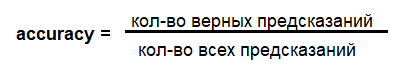

Для начала необходимо выгрузить данные. Скачайте данные из Kaggle и загрузите в файлы, либо выгрузите из хранилища

In [ ]:
# Загружаем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)  # для воспроизводимости результатов

In [ ]:
# Чтение файлов
train_data = pd.read_csv("https://raw.githubusercontent.com/dsindy/kaggle-titanic/master/data/train.csv")
test_data = pd.read_csv("https://raw.githubusercontent.com/dsindy/kaggle-titanic/master/data/test.csv")

Попробуем сделать свой первый сабмит! Сделаем случайное предсказание.

In [ ]:
# Создание случайных предсказаний (0 или 1) для тестовых данных
random_predictions = np.random.choice([0, 1], size=len(test_data))

# Создание датафрейма с предсказаниями
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': random_predictions
})

# Сохранение результатов
submission.to_csv('random_submission.csv', index=False)

во вкладке Файлы скачайте файл random_submission.csv и отправьте его в систему Kaggle:
1. На странице соревнования нажмите Submit Predictions
2. Загрузите файл и нажмите кнопку Make Submission
3. После этого вы увидите ваш счёт (Score) в таблице My Submissions

Поздравляю с первым сабмитом! Значение метрики, которое вы получили точка отсчета самого плохого предсказания. Вы должны создать модель, которая привысит это значение

# Блок 1. Исследование структуры данных и первичная обработка

**Цель**: Понять структуру и основные характеристики набора данных Титаника

### Задание 2. Исследуйте струкртуру данных (3 балла)

Выведите базовые статитсики об обучающей и тествой выборке. Полезные функции:
- [pd.DataFrame.head()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.head.html)
- [pd.DataFrame.shape](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.shape.html)
- [pd.DataFrame.dtypes](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dtypes.html)
- [pd.DataFrame.describe()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html)
- [pd.DataFrame.info()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.info.html)

Изучите данные, посмотрите, какой вид они имеют.
Вопросы для самопроверки:
1. Сколько строк и столбцов содержится в обучающей выборке? А в тестовой?
2. Какие типы данных имеют столбцы? Какие признаки из них категориальные, а какие числовые?
3. Есть ли пропуски в обучающей выборке? А в тестовой выборке?
4. Есть ли дубликаты в данных?

In [ ]:
# ваш код здесь

# Блок 2. Разведочный анализ данных

## Задание 3. Разведочный анализ данных (7 баллов)

Ниже приведён ряд графиков. Внимательно изучите распределение данных и постарайтесь выявить закономерности. По необходимости, нарисуйте другие графики.

Обратите внимание: существуют ли группы пассажиров, которые имели значительное преимущество по выживаемости? Подумайте, какие признаки — пол, возраст, класс билета или другие — могли сыграть ключевую роль.

Попробуйте использовать найденную закономерность на практике: сформулируйте простое правило на основе одного или нескольких признаков и сделайте предсказание для тестовой выборки. Например, если возраст пасажира более 50 лет, он погибнет (предсказание 0), иначе выживет (предсказание 1). Загрузите результат на Kaggle и посмотрите, как это отразится значении метрики.

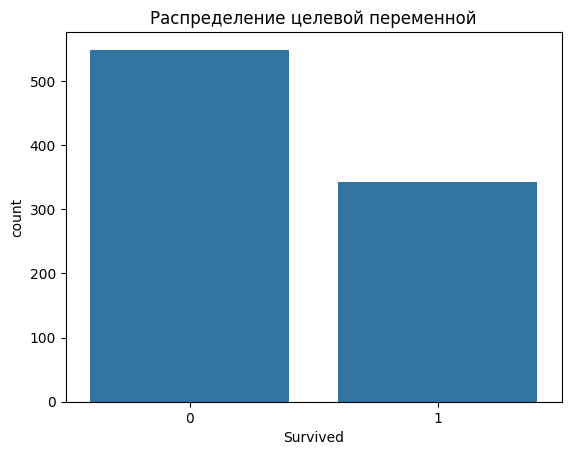

In [ ]:
sns.countplot(x='Survived', data=train_data)
plt.title('Распределение целевой переменной')
plt.show()

### Влияние возраста на целевую переменную

Text(0.5, 1.0, 'Количество пассажиров по возрасту')

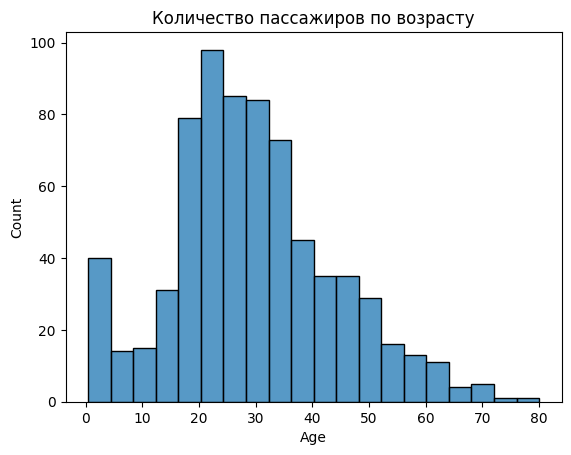

In [ ]:
sns.histplot(data=train_data, x='Age', bins=20, kde=False)
plt.title('Количество пассажиров по возрасту')

Text(0.5, 1.0, 'Распределение возраста по выживаемости')

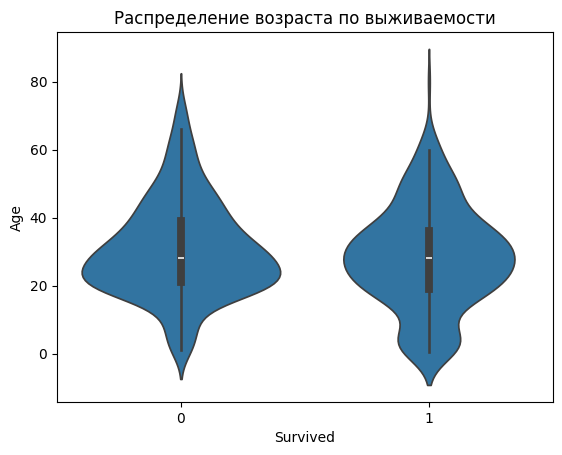

In [ ]:
sns.violinplot(x='Survived', y='Age', data=train_data)
plt.title('Распределение возраста по выживаемости')

### Влияние гендера на целевую переменную

Text(0.5, 1.0, 'Выживаемость в зависимости от пола')

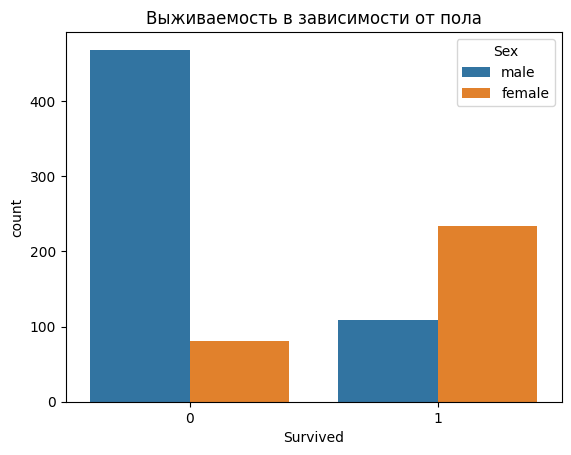

In [ ]:
sns.countplot(x='Survived', hue='Sex', data=train_data)
plt.title('Выживаемость в зависимости от пола')

С помощью скрипичного графика в Seaborn мы можем увидеть взаимосвязь между полом, возрастом и тем, выжил пассажир или нет.

Text(0.5, 1.0, 'Распределение возраста по полу и выживаемости')

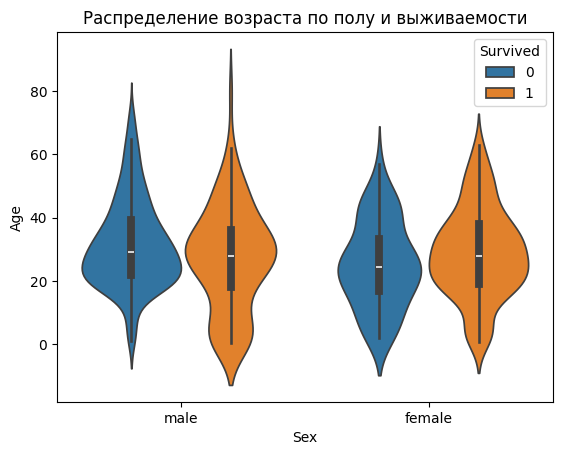

In [ ]:
sns.violinplot(x='Sex', y='Age', hue='Survived', data=train_data)
plt.title('Распределение возраста по полу и выживаемости')

### Влияние класса пасажира на целевую переменную

Text(0.5, 1.0, 'Выживаемость в зависимости от класса пассажира')

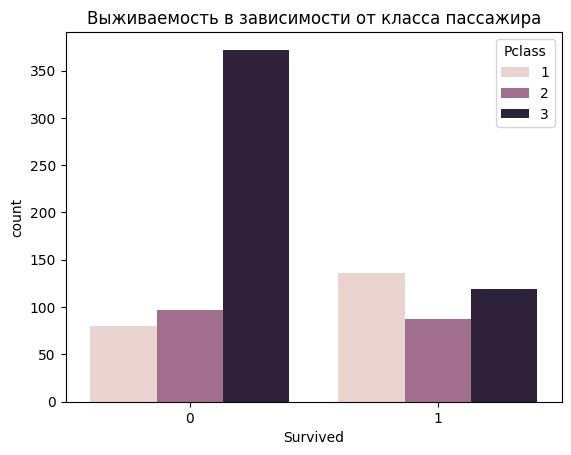

In [ ]:
sns.countplot(x='Survived', hue='Pclass', data=train_data)
plt.title('Выживаемость в зависимости от класса пассажира')

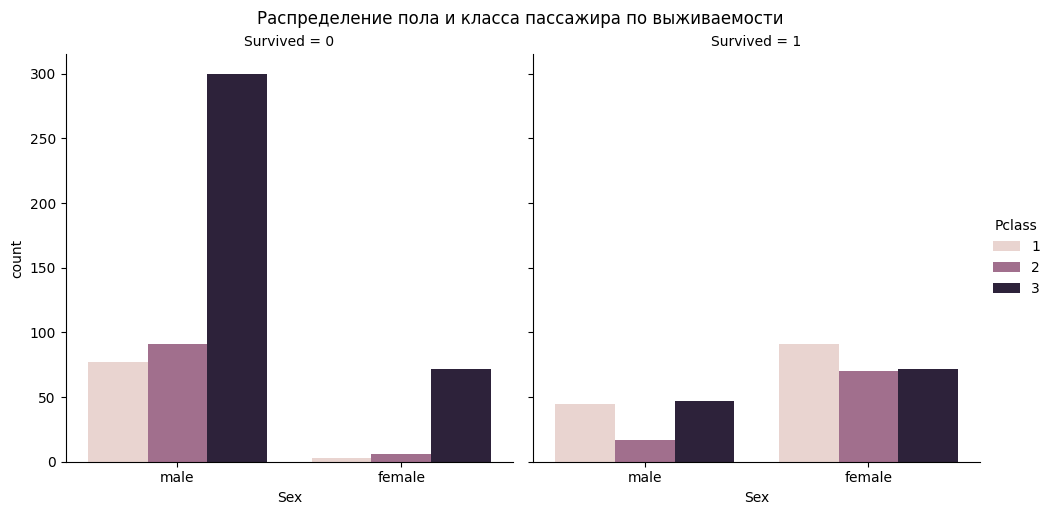

In [ ]:
g = sns.catplot(x='Sex', hue='Pclass', col='Survived', kind='count', data=train_data)
g.figure.suptitle('Распределение пола и класса пассажира по выживаемости', y=1.02)
plt.show()

Text(0.5, 1.0, 'Распределение возраста по классу пассажира и выживаемости')

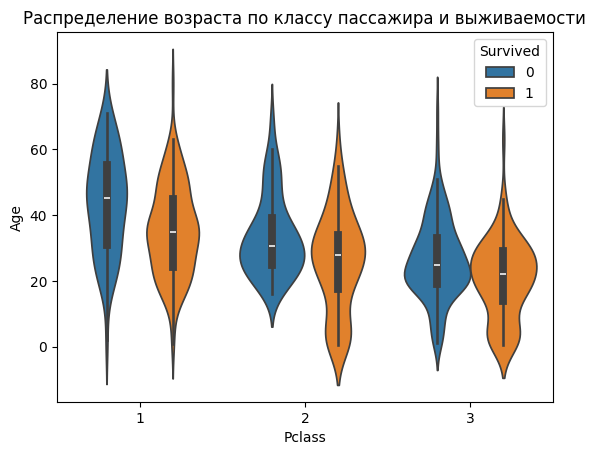

In [ ]:
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=train_data)
plt.title('Распределение возраста по классу пассажира и выживаемости')

### Корреляция признаков




<Axes: >

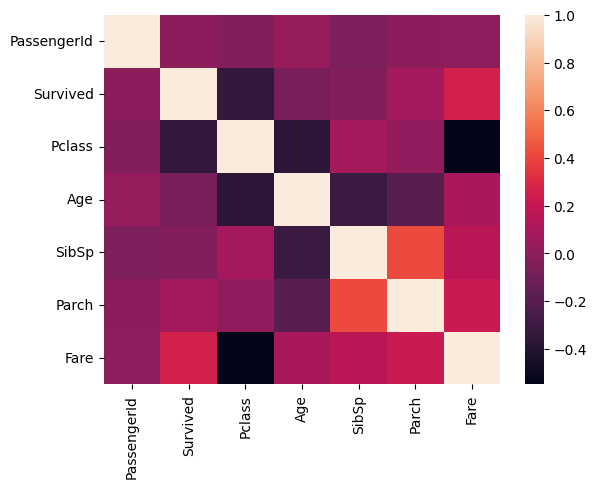

In [ ]:
sns.heatmap(train_data.corr(numeric_only=True))

### Саббмит на основе найденной закономерности

Попробуйте использовать найденную закономерность на практике: сформулируйте простое правило на основе одного или нескольких признаков и сделайте предсказание для тестовой выборки. Загрузите результат на Kaggle и посмотрите, как это отразится значении метрики.

In [ ]:
# ваш код здесь

# Блок 3. Обработка данных
Обработайте данные по следующим пунктам. Сначала выполните преобразования на train_data, затем применяйте эти преобразвания к test_data

### Задание 4. Обработка пустых значений (10 баллов)

Выведите сколько пропусков в колонках. Изучите природу пропусков в колонках. Для каждой колонки определите способ избавления от пропусков и используйте его.

Вопросы для самопроверки:
- Какие колонки имеют пропуски?
- Сколько пропусков в каждой?
- Можно ли удалить колонку?
- Можно ли удалить строки с пропусками?
- Пропуск в категориальной колонке или в числовой?
- Как лучше заполнить пропуски?

In [ ]:
# ваш код здесь

### Задание 5. Обработка категориальных переменных (10 баллов)

Определите, какие из признаков являются категориальными. Большинство алгоритмов машинного обучения работают только с числовыми данными, поэтому категориальные признаки необходимо преобразовать перед подачей в модель.

Выберите категориальные признаки, которые, на ваш взгляд, могут быть полезны для предсказания выживаемости, и обработайте их одним из подходящих способов.

In [ ]:
# ваш код здесь

### Задание 6. Генерация новых признаков (10 баллов)

Сконструируйте новые признаки, используя различные методы генерации, опираясь на логику предметной области и результаты ваших наблюдений.

In [ ]:
# ваш код здесь

## Задание 7. Нормализация признаков (5 баллов)

Отберите признаки и нормализуйте их

### Отбор признаков

Необходимо сформировать из датафрейма матрицу признаков X и целевую переменную y. Определите, какие признаки вы хотите использовать для обучения модели.

In [ ]:
y_train = train_data['Survived']

# Укажите признаки, на которых вы хотите обучить модель
features = []
X_train = train_data[features]
X_test = test_data[features]

Выполните масштабирование признаков одним из способов.

In [ ]:
# ваш код здесь

### Задание 7. Документирование обработки данных (3 балла)

В реальных проектах данные проходят через множество этапов обработки, и важно не потерять информацию о том, что именно и в какой версии было сделано. Хорошая практика — сохранять каждую версию предобработанных данных и вести таблицу с описанием изменений.

Заведите таблицу и заполняйте её по мере работы с данными. Пример:

| Версия | Описание изменений | Масштабирование |
|--------|--------------------|---------|
| v1.0 | Пропуски в `Age` заполнены медианой,  Добавлен One-Hot Encoding для `Embarked` и `Sex`| StandartScaler |
| v1.1 | Добавлен новый признак Age_squad |StandartScaler |
| ... | ... | ... |

Каждый раз, когда вы вносите изменения в предобработку, сохраняйте новую версию файла и фиксируйте в таблице, что изменилось. Это позволит вам легко вернуться к любой из предыдущих версий и понять, какие преобразования привели к улучшению результата.

ПРИМЕЧАНИЕ: после завершения сессии Colab удаляет все сохраненные в проекте файлы. Скачивайте версии датафреймов на свой компьютер или гугл диск.

In [ ]:
# Ваш код здесь

# Блок 4. Обучение модели

## Задание 8. Обучение модели. (10 баллов)
Обучите модель машинного обучения на отобранных признаках. Некоторые подходящие модели из библиотеки `sklearn`:
- KNeighborsClassifier
- LogisticRegression
- DecisionTreeClassifier
- RandomForestClassifier



Для оценки качества модели оценивается метрика accuracy - это доля объектов, для которых мы правильно предсказали класс

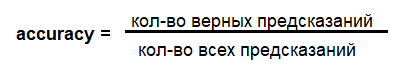

Какое значение метрики при обучении?

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = ...  # ваш код здесь

Сделайте предсказание модели, создайте новый сабмит и отправьте на платформу kaggle

In [ ]:
# ваш код здесь

В проектах часто приходится перебирать множество моделей с разными параметрами, и важно фиксировать результаты каждого эксперимента. Хорошая практика — сохранять каждую версию обученной модели и вести таблицу с описанием конфигурации и результатов.

Заведите таблицу следующего вида и заполняйте её по мере экспериментов:

| Алгоритм | Гиперпараметры | Версия данных | Результат на train | Результат на Kaggle |
|--------|----------|--------------------|---------------|---------------------|
| Logistic Regression | `C=1.0`, `max_iter=100` | `v1.0` | 0.765 | 0.761 |
| Logistic Regression | `C=0.5`, `max_iter=200` | `v1.0` | 0.772 | 0.675 |
| Random Forest | `n_estimators=100`, `max_depth=5` | `v1.1` | 0.781 | 0.651 |
| ... | ... | ... | ... | ... |

Каждый раз, когда вы обучаете новую модель, фиксируйте в таблице информацию об обучении. Это позволит вам воспроизвести любой эксперимент и понять, какие изменения привели к улучшению результата.